In [132]:
from matplotlib.backend_bases import cursors

from db.db_connection import create_connection
import pandas as pd
from utils.formatter import prettify
import warnings
warnings.filterwarnings("ignore")

connection = create_connection()

query = """
SELECT * FROM v_transactions_overview
"""

df = pd.read_sql(query, connection)

prettify(df)


,ID,Customer,Platform,Asset,status,currency,Date,Amount,Buy Price,Buy Price (EUR),Exchange Fee,Service Fee,Referral Bonus
0,1,Anna,Binance,ETH,completed,USD,2025-04-11,0.0792,1533.13,1351.26,4.86,2.89,0.14
1,2,Lisa,Binance,ETH,completed,USD,2025-04-13,0.1529,1653.78,1457.59,5.31,4.77,0.78
2,3,Tom,Binance,ETH,pending,USD,2025-04-14,0.0280,1601.46,1407.63,2.25,2.81,0.86
3,25,Mark,Binance,ETH,completed,USD,2025-05-25,0.1303,2539.65,2247.28,4.22,1.32,2.58
4,26,Lisa,Binance,ETH,completed,USD,2025-05-27,0.0078,2555.52,2250.37,5.02,3.27,0.34
...,...,...,...,...,...,...,...,...,...,...,...,...,...
201,175,Anna,Kraken,BTC,pending,USD,2026-02-13,0.0127,65887.20,55544.88,8.52,3.27,2.17
202,180,David,Kraken,BTC,completed,USD,2026-02-17,0.0484,69520.92,58786.20,9.98,2.24,0.57
203,198,Lisa,Kraken,BTC,pending,USD,2026-03-10,0.0463,69130.60,59385.25,7.78,2.78,1.43
204,204,Tom,Kraken,BTC,completed,USD,2026-03-23,0.0349,68074.06,58705.02,2.79,2.48,0.62


In [111]:
df["total_buy_eur"] = df["amount"] * df["buy_price_eur"]
prettify(df)

,ID,Customer,Platform,Asset,status,currency,Date,Amount,Buy Price,Buy Price (EUR),Exchange Fee,Service Fee,Referral Bonus,Total Investment (EUR)
0,1,Anna,Binance,ETH,completed,USD,2025-04-11,0.0792,1533.13,1351.26,4.86,2.89,0.14,107.019792
1,2,Lisa,Binance,ETH,completed,USD,2025-04-13,0.1529,1653.78,1457.59,5.31,4.77,0.78,222.865511
2,3,Tom,Binance,ETH,pending,USD,2025-04-14,0.0280,1601.46,1407.63,2.25,2.81,0.86,39.413640
3,25,Mark,Binance,ETH,completed,USD,2025-05-25,0.1303,2539.65,2247.28,4.22,1.32,2.58,292.820584
4,26,Lisa,Binance,ETH,completed,USD,2025-05-27,0.0078,2555.52,2250.37,5.02,3.27,0.34,17.552886
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201,175,Anna,Kraken,BTC,pending,USD,2026-02-13,0.0127,65887.20,55544.88,8.52,3.27,2.17,705.419976
202,180,David,Kraken,BTC,completed,USD,2026-02-17,0.0484,69520.92,58786.20,9.98,2.24,0.57,2845.252080
203,198,Lisa,Kraken,BTC,pending,USD,2026-03-10,0.0463,69130.60,59385.25,7.78,2.78,1.43,2749.537075
204,204,Tom,Kraken,BTC,completed,USD,2026-03-23,0.0349,68074.06,58705.02,2.79,2.48,0.62,2048.805198


In [112]:
market_prices_df = pd.read_sql("SELECT * FROM market_prices", connection)
transactions_df  = pd.read_sql("SELECT * FROM transactions", connection)

market_prices_df.head(10)


,price_id,asset_id,price_date,price_eur,created_at,updated_at,price_usd,eur_rate
0,1,1,2025-04-10,74554.941588,2026-04-02 11:23:33,2026-04-02 11:23:33,82622.17,0.90236
1,2,1,2025-04-11,70153.841453,2026-04-02 11:23:34,2026-04-02 11:23:34,79596.36,0.88137
2,3,1,2025-04-12,73540.885424,2026-04-02 11:23:34,2026-04-02 11:23:34,83439.29,0.88137
3,4,1,2025-04-13,75185.353593,2026-04-02 11:23:34,2026-04-02 11:23:34,85305.10,0.88137
4,5,1,2025-04-14,73482.612844,2026-04-02 11:23:35,2026-04-02 11:23:35,83600.82,0.87897
5,6,1,2025-04-15,74640.970426,2026-04-02 11:23:35,2026-04-02 11:23:35,84523.45,0.88308
6,7,1,2025-04-16,73673.763240,2026-04-02 11:23:35,2026-04-02 11:23:35,83656.49,0.88067
7,8,1,2025-04-17,74036.635509,2026-04-02 11:23:36,2026-04-02 11:23:36,84105.78,0.88028
8,9,1,2025-04-18,74762.980201,2026-04-02 11:23:36,2026-04-02 11:23:36,84930.91,0.88028
9,10,1,2025-04-19,74325.341602,2026-04-02 11:23:37,2026-04-02 11:23:37,84433.75,0.88028


In [113]:
prettify(transactions_df.head())

,ID,client_id,platform_id,asset_id,status_id,Date,Amount,Buy Price,currency_id,Buy Price (EUR),Exchange Fee,Service Fee,Referral Bonus,created_at,updated_at,transaction_type
0,1,1,1,2,2,2025-04-11,0.0792,1533.13,1,1351.26,4.86,2.89,0.14,2026-04-03 11:03:14,2026-04-03 11:03:14,BUY
1,2,5,1,2,2,2025-04-13,0.1529,1653.78,1,1457.59,5.31,4.77,0.78,2026-04-03 11:03:14,2026-04-03 11:03:14,BUY
2,3,4,1,2,1,2025-04-14,0.0280,1601.46,1,1407.63,2.25,2.81,0.86,2026-04-03 11:03:14,2026-04-03 11:03:14,BUY
3,4,3,3,1,1,2025-04-15,0.0016,84611.23,1,74718.49,8.31,4.23,2.64,2026-04-03 11:03:14,2026-04-03 11:03:14,BUY
4,5,3,2,2,2,2025-04-17,0.4384,1583.80,1,1394.19,9.69,4.24,2.71,2026-04-03 11:03:14,2026-04-03 11:03:14,BUY


In [114]:
len(transactions_df)

206

In [115]:
len(market_prices_df)

712

In [116]:
market_prices_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 712 entries, 0 to 711
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   price_id    712 non-null    int64         
 1   asset_id    712 non-null    int64         
 2   price_date  712 non-null    datetime64[us]
 3   price_eur   712 non-null    float64       
 4   created_at  712 non-null    datetime64[us]
 5   updated_at  712 non-null    datetime64[us]
 6   price_usd   712 non-null    float64       
 7   eur_rate    712 non-null    float64       
dtypes: datetime64[us](3), float64(3), int64(2)
memory usage: 44.6 KB


In [117]:
market_prices_df["price_date"].min()

Timestamp('2025-04-10 00:00:00')

In [118]:
market_prices_df["price_date"].max(),market_prices_df["price_date"].min(),

(Timestamp('2026-03-31 00:00:00'), Timestamp('2025-04-10 00:00:00'))

In [119]:
print("MIN: ", market_prices_df["price_date"].min())
print("MAX: ", market_prices_df["price_date"].max())

MIN:  2025-04-10 00:00:00
MAX:  2026-03-31 00:00:00


In [120]:
market_prices_df["price_date"] = pd.to_datetime(market_prices_df["price_date"]) #datetime format

In [121]:
market_prices_df["price_date"] = market_prices_df["price_date"].dt.strftime("%Y-%m-%d") #string format

In [122]:
market_prices_df.isnull().sum()

price_id      0
asset_id      0
price_date    0
price_eur     0
created_at    0
updated_at    0
price_usd     0
eur_rate      0
dtype: int64

In [123]:
transactions_df.isnull().sum()

transaction_id        0
client_id             0
platform_id           0
asset_id              0
status_id             0
transaction_date      0
amount                0
buy_price             0
currency_id           0
buy_price_eur         0
exchange_fee_eur      0
service_fee_eur       0
referral_bonus_eur    0
created_at            0
updated_at            0
transaction_type      0
dtype: int64

In [124]:
market_prices_df["asset_id"].nunique()

2

In [125]:
transactions_df["asset_id"].nunique()

2

In [126]:
query= """
SELECT
    COUNT(*) AS total_rows,
    SUM(price_usd IS NULL) AS price_usd_nulls,
    SUM(price_eur IS NULL) AS price_eur_nulls,
    SUM(eur_rate IS NULL) AS eur_rate_nulls
FROM market_prices;
"""


df_check = pd.read_sql(query, connection)
df_check

,total_rows,price_usd_nulls,price_eur_nulls,eur_rate_nulls
0,712,0.0,0.0,0.0


In [127]:
df_check2=pd.DataFrame({
    "total_rows": [len(market_prices_df)],
    "price_usd_nulls":[market_prices_df["price_usd"].isna().sum()],
    "price_eur_nulls":[market_prices_df["price_eur"].isna().sum()],
    "eur_rate_nulls":[market_prices_df["eur_rate"].isna().sum()]
})
df_check2

,total_rows,price_usd_nulls,price_eur_nulls,eur_rate_nulls
0,712,0,0,0


In [128]:
query="""
SELECT
    mp.price_date,
    mp.price_eur
FROM market_prices mp
JOIN assets a ON mp.asset_id = a.asset_id
WHERE a.asset_symbol='BTC'
ORDER BY mp.price_date;
"""

btc_df = pd.read_sql(query, connection)
btc_df.head()

,price_date,price_eur
0,2025-04-10,74554.941588
1,2025-04-11,70153.841453
2,2025-04-12,73540.885424
3,2025-04-13,75185.353593
4,2025-04-14,73482.612844


In [129]:
# перетворюємо дату (важливо для графіка!)
btc_df["price_date"] = pd.to_datetime(btc_df["price_date"])

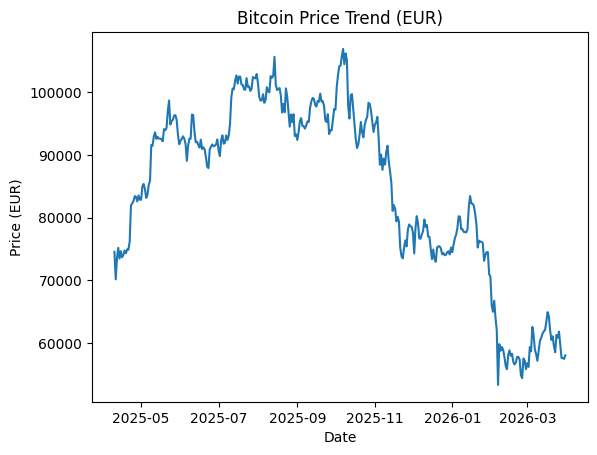

In [130]:
#graffik - Ich verwende matplotlib für die Visualisierung der Daten
import matplotlib.pyplot as plt

plt.figure()

plt.plot(btc_df["price_date"], btc_df["price_eur"])

plt.title("Bitcoin Price Trend (EUR)")
plt.xlabel("Date")
plt.ylabel("Price (EUR)")

plt.show()



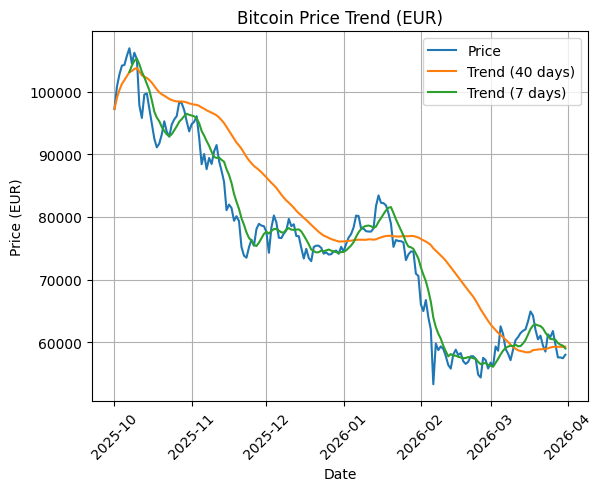

In [131]:
plt.figure()

#період
btc_df= btc_df[
    (btc_df["price_date"]>="2025-10-01")&
    (btc_df["price_date"]<="2026-04-01")
]

#*середнє значення ціни за останні 40 і 7 днів
btc_df["rolling_avg_40"]=btc_df["price_eur"].rolling(window=40, min_periods=1).mean()
btc_df["rolling_avg_7"]=btc_df["price_eur"].rolling(window=7).mean()

# реальна ціна
plt.plot(btc_df["price_date"], btc_df["price_eur"], label="Price")
# тренд (rolling avg)
plt.plot(btc_df["price_date"], btc_df["rolling_avg_40"], label="Trend (40 days)")
plt.plot(btc_df["price_date"], btc_df["rolling_avg_7"], label="Trend (7 days)")

plt.title("Bitcoin Price Trend (EUR)")
plt.xlabel("Date")
plt.ylabel("Price (EUR)")

plt.legend()
plt.grid()
plt.xticks(rotation=45)

plt.show()

#Ein 40-Tage-Durchschnitt zeigt den langfristigen Trend,
# während ein 7-Tage-Durchschnitt kurzfristige Schwankungen zeigt
# Der gleitende Durchschnitt beginnt erst nach 40 Tagen, weil vorher nicht genügend Daten vorhanden sind.

In [134]:
cursor = connection.cursor()
cursor.execute("DROP VIEW IF EXISTS v_transactions_overview;")
cursor.close()
print("View deleted")
connection.close()

View deleted
